In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/heart_disease_risk_2026.csv')

In [3]:
df

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,8996,36,Female,108,63,178,68,82,158,96,...,False,Never,13.0,306,8.6,51.1,False,7144,58.1,0
8996,8997,44,Female,112,73,213,54,139,102,125,...,False,Former,3.4,76,6.5,37.1,False,7395,68.9,0
8997,8998,57,Female,144,93,198,66,113,79,102,...,False,Never,3.9,194,6.2,46.3,False,7424,70.2,0
8998,8999,61,Female,130,70,220,68,135,109,104,...,False,Former,3.9,139,5.0,66.5,False,5716,43.8,1


In [4]:
df.shape

(9000, 27)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

In [6]:
df = df.drop('patient_id', axis=1)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
age,0
sex,0
resting_bp_systolic,0
resting_bp_diastolic,0
cholesterol_total,0
hdl,0
ldl,0
triglycerides,0
fasting_blood_sugar,0
hba1c,0


In [9]:
num_cols = df.select_dtypes(include= np.number).columns.to_list()
cat_cols = df.select_dtypes(include='object').columns.to_list()

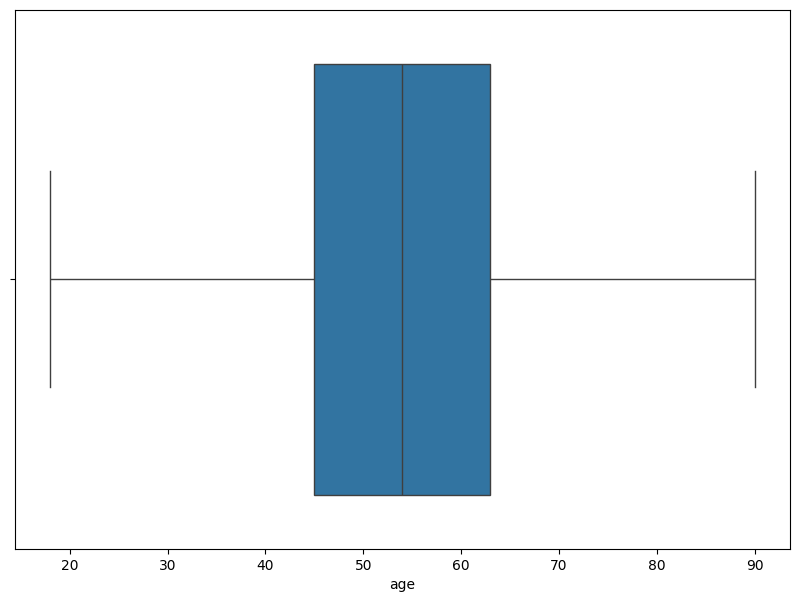

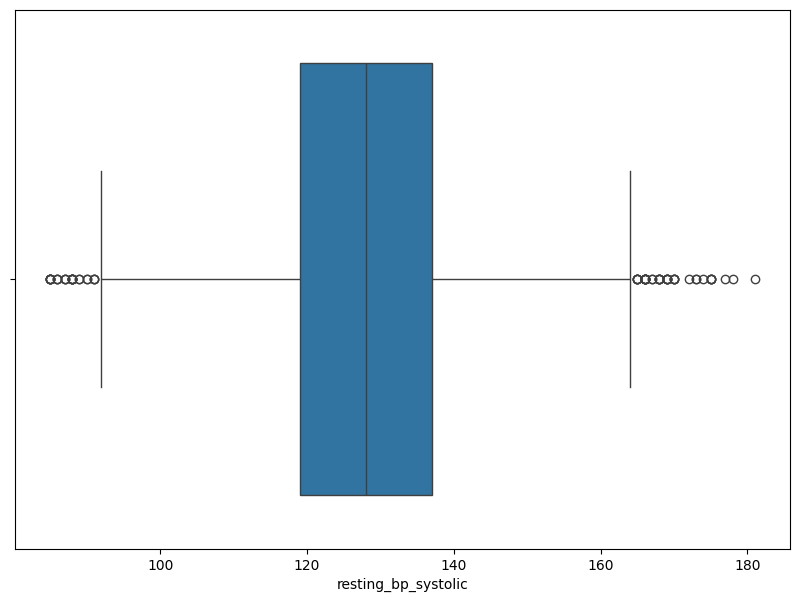

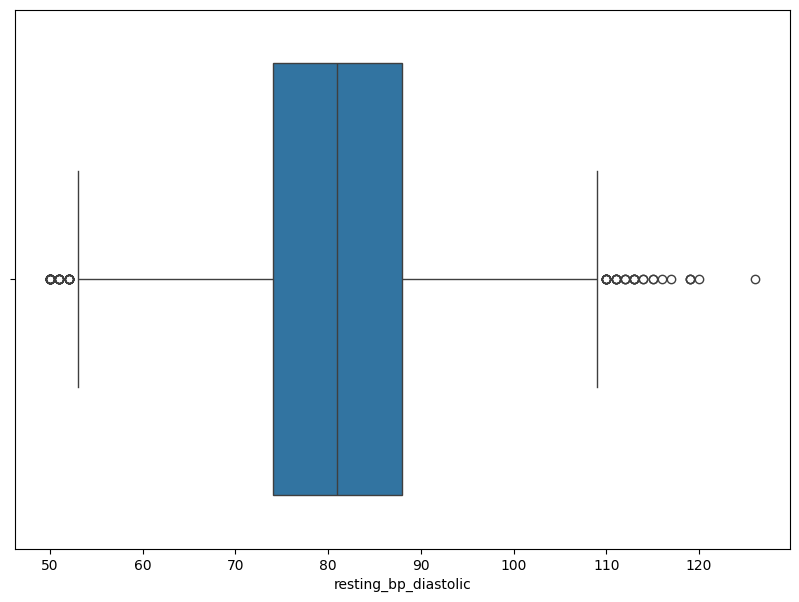

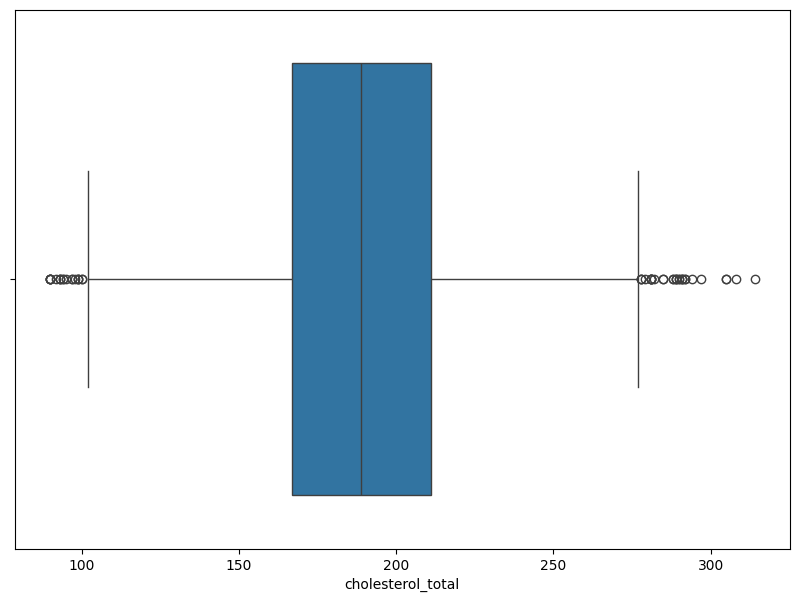

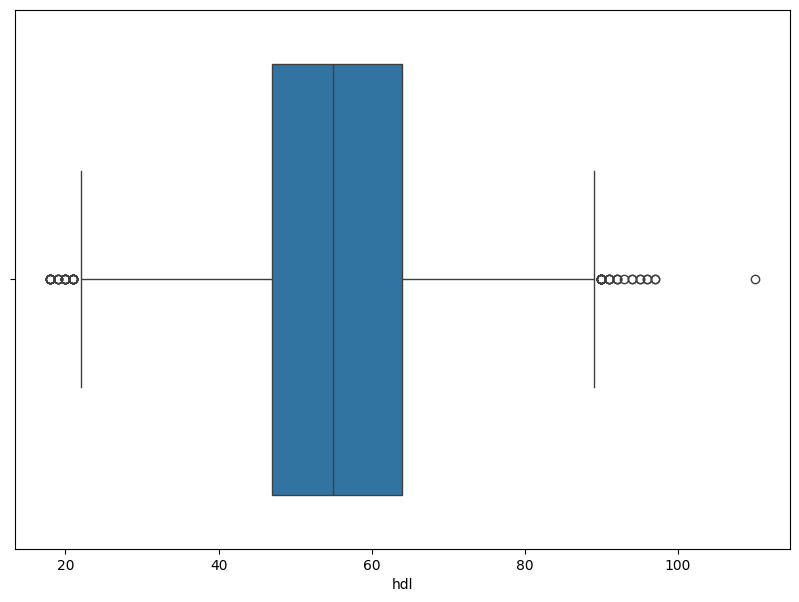

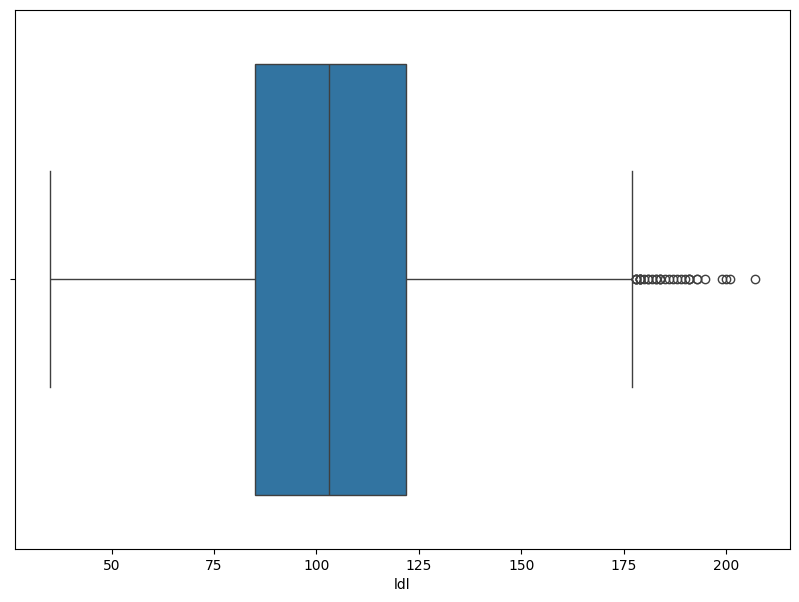

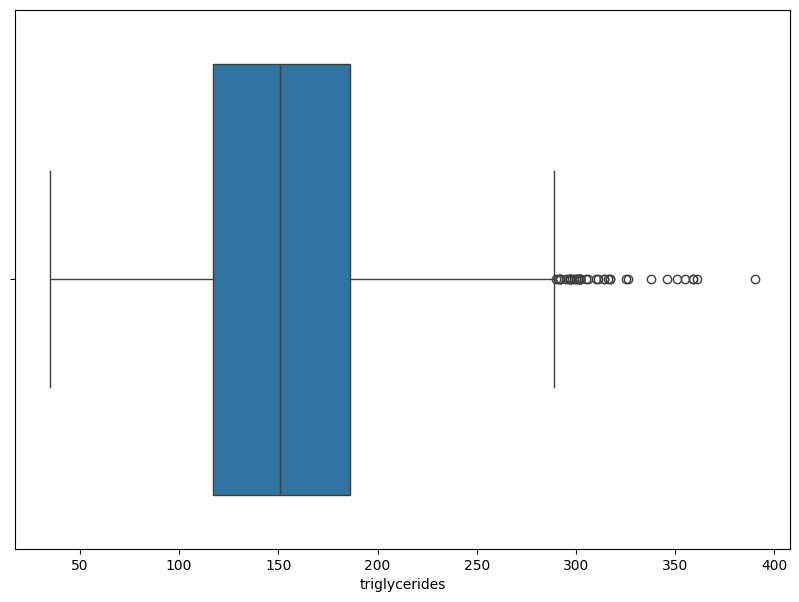

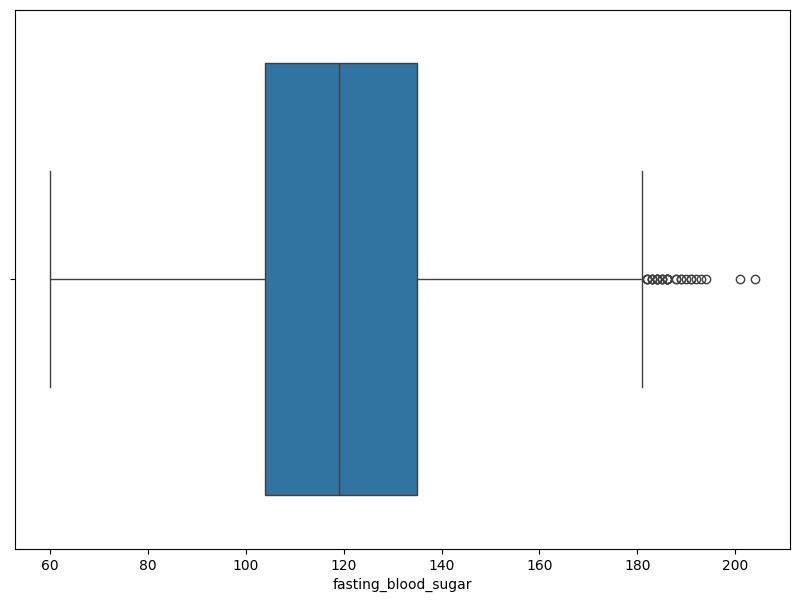

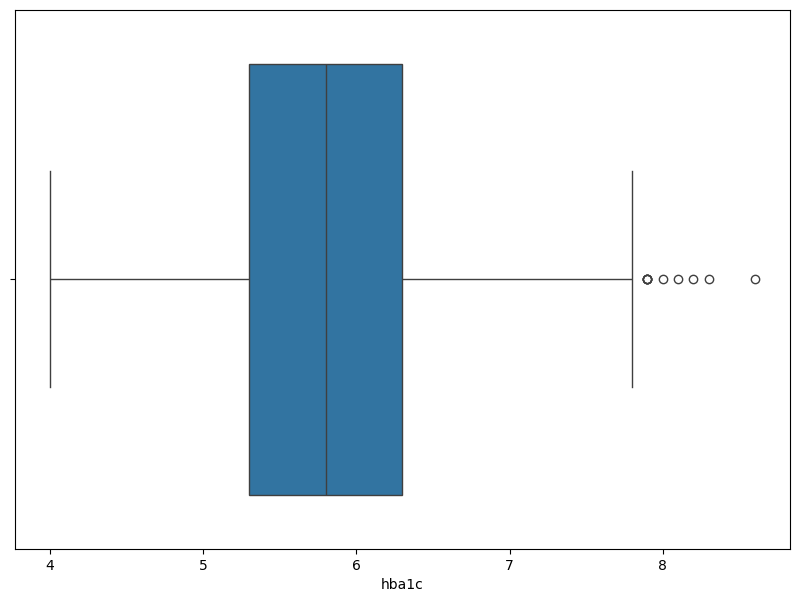

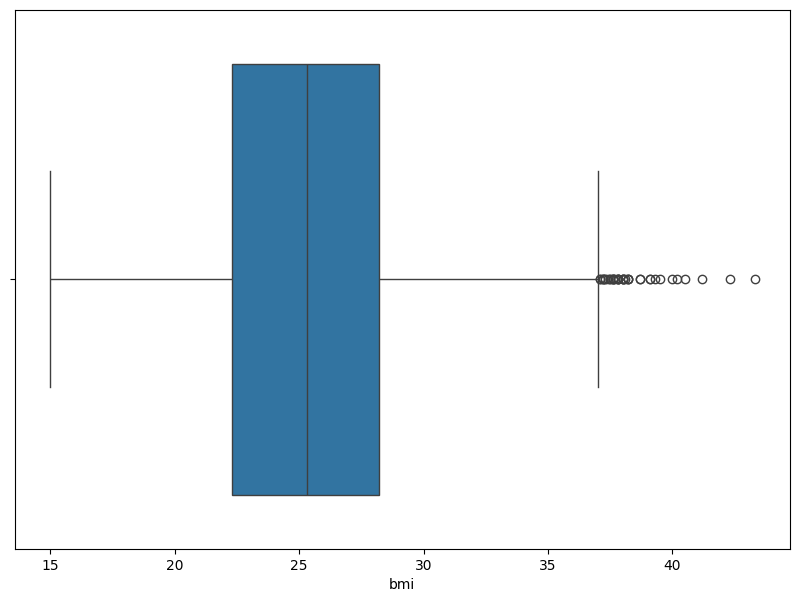

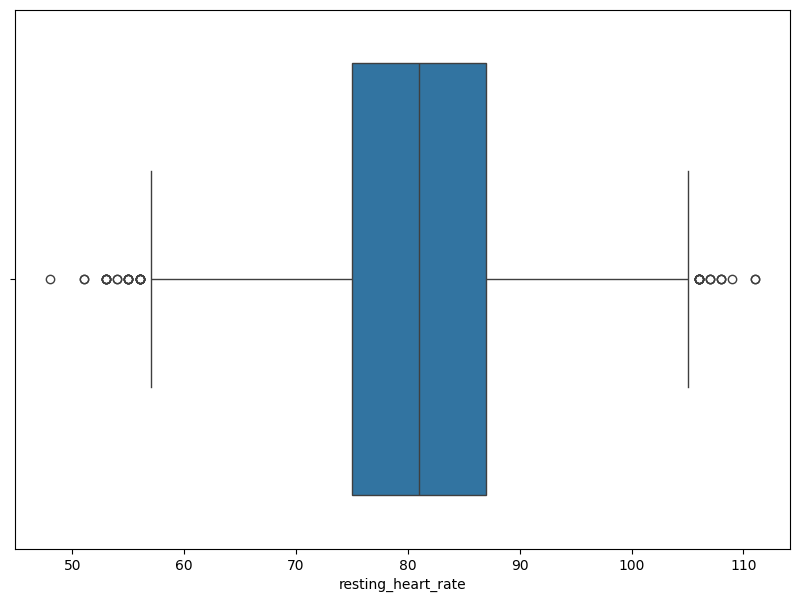

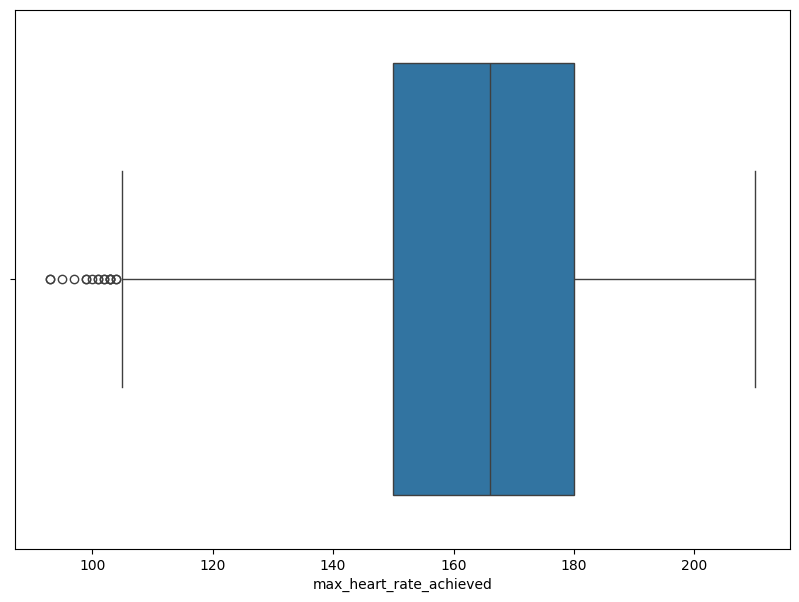

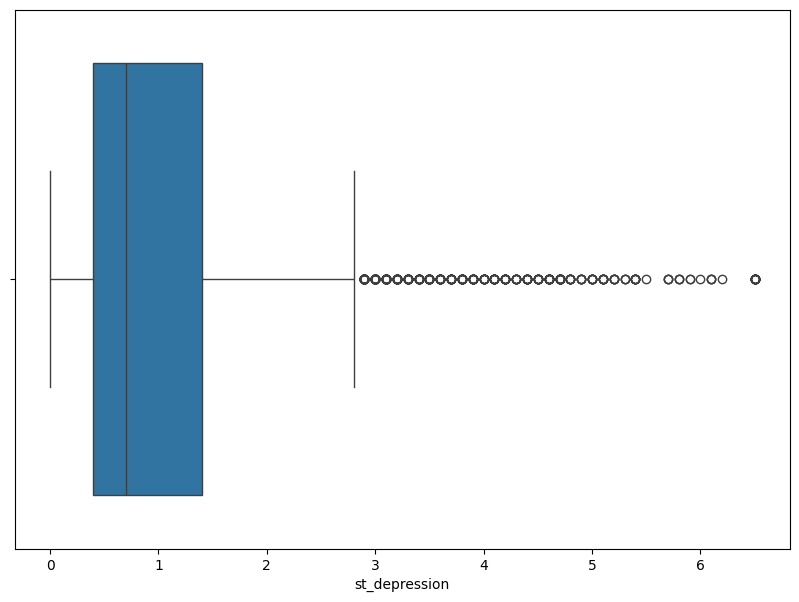

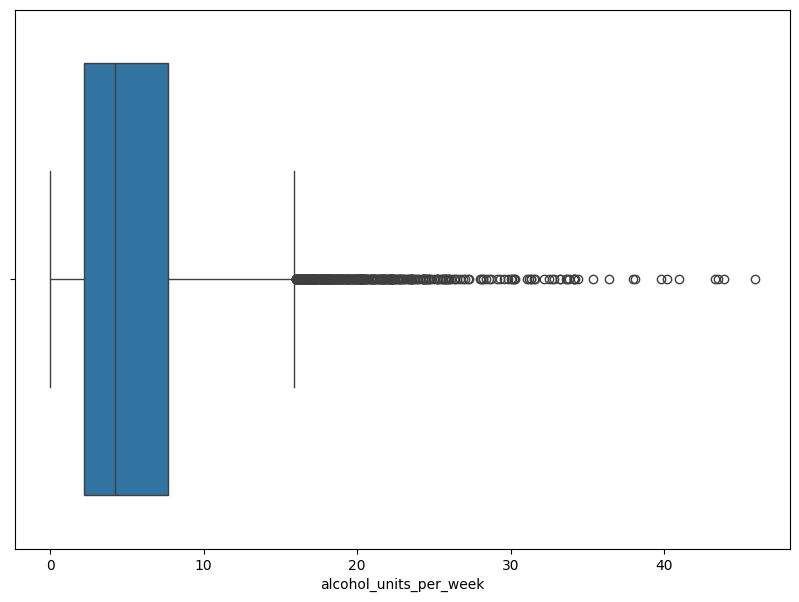

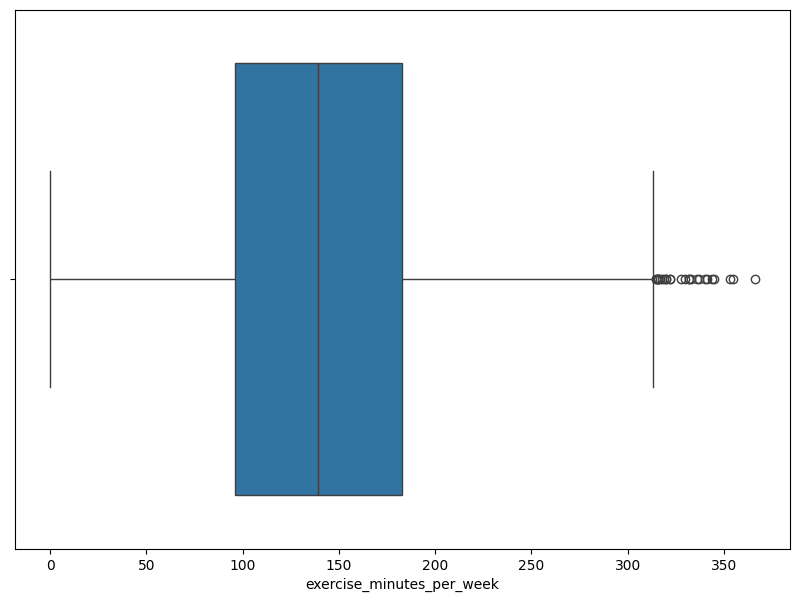

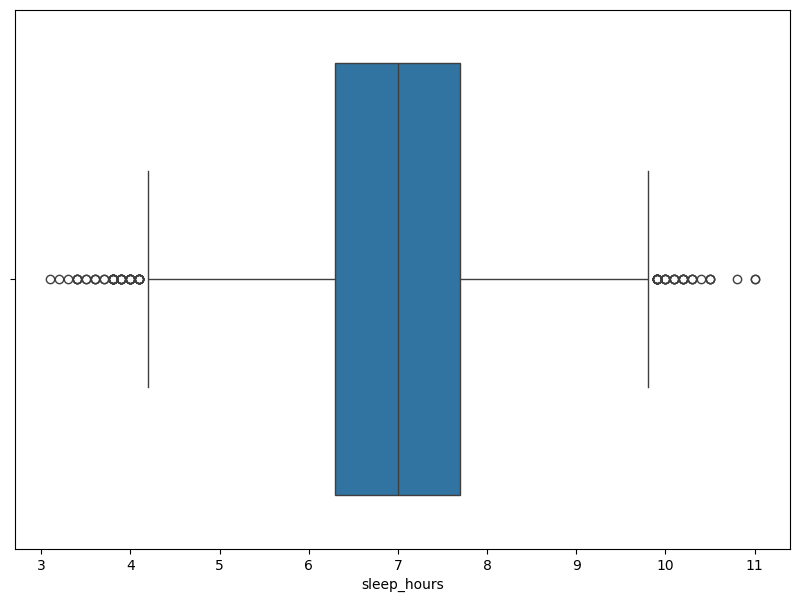

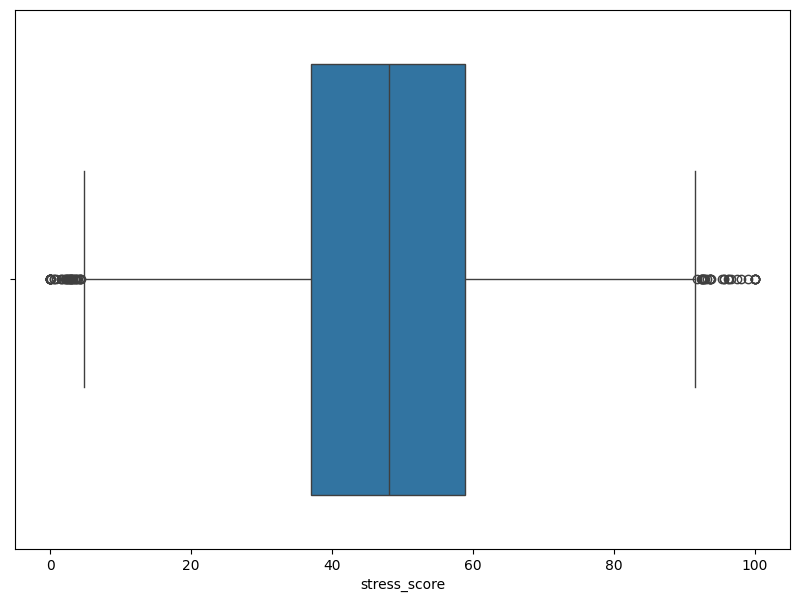

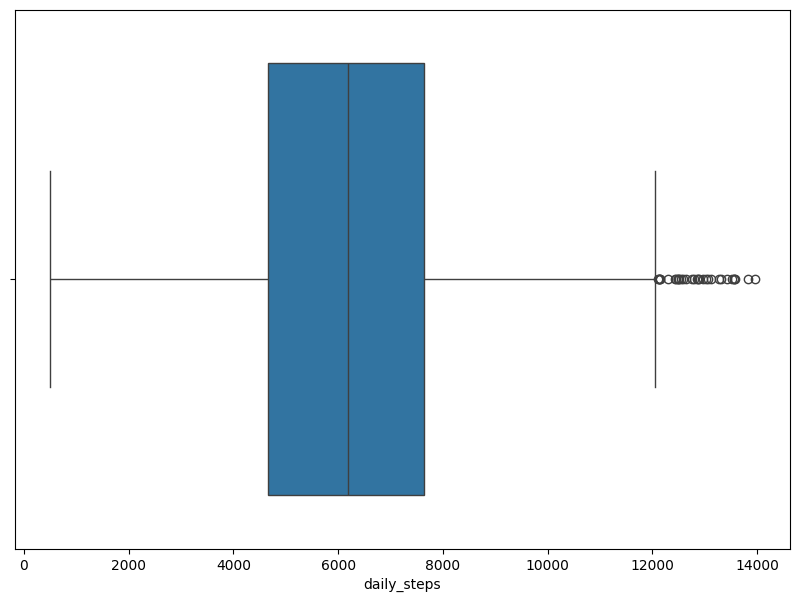

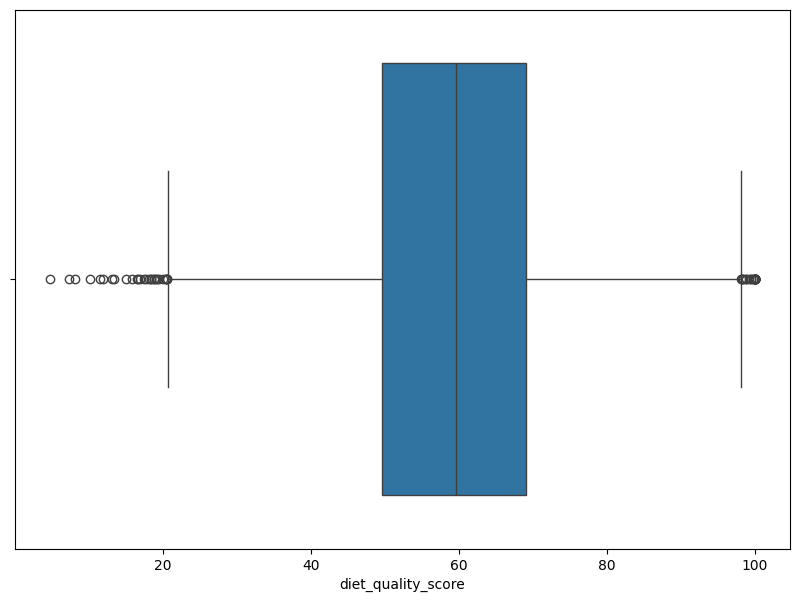

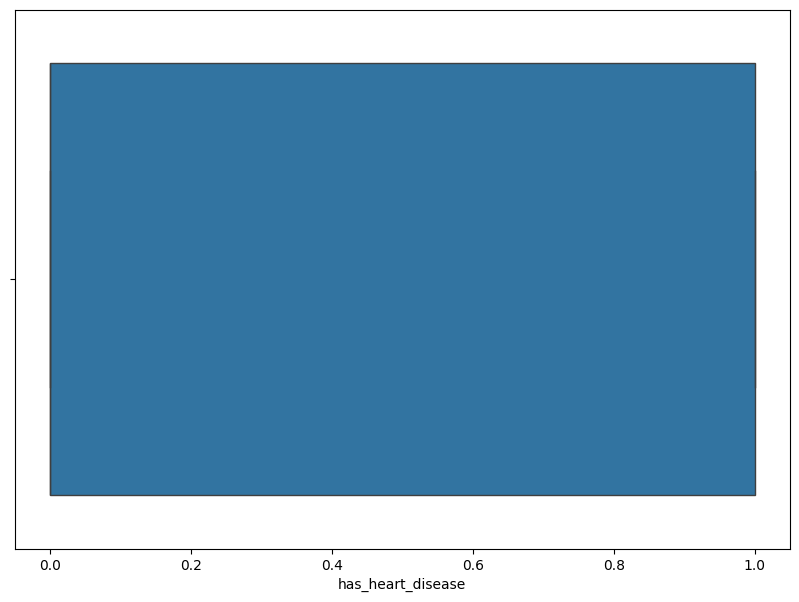

In [16]:
for col in num_cols:
  plt.figure(figsize=(10 , 7))
  sns.boxplot(x = df[col])
plt.show()

In [17]:
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  df = df[(df[col] >= lower) & (df[col] <= upper)]

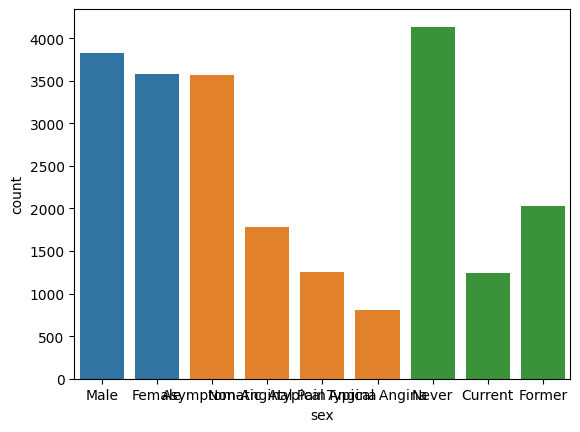

In [18]:
for col in cat_cols:
  sns.countplot(x=col, data=df)

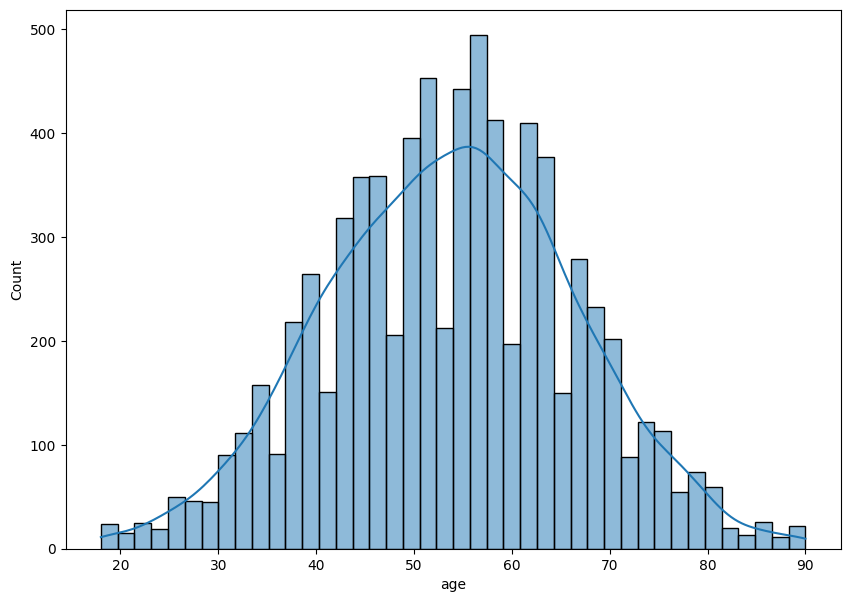

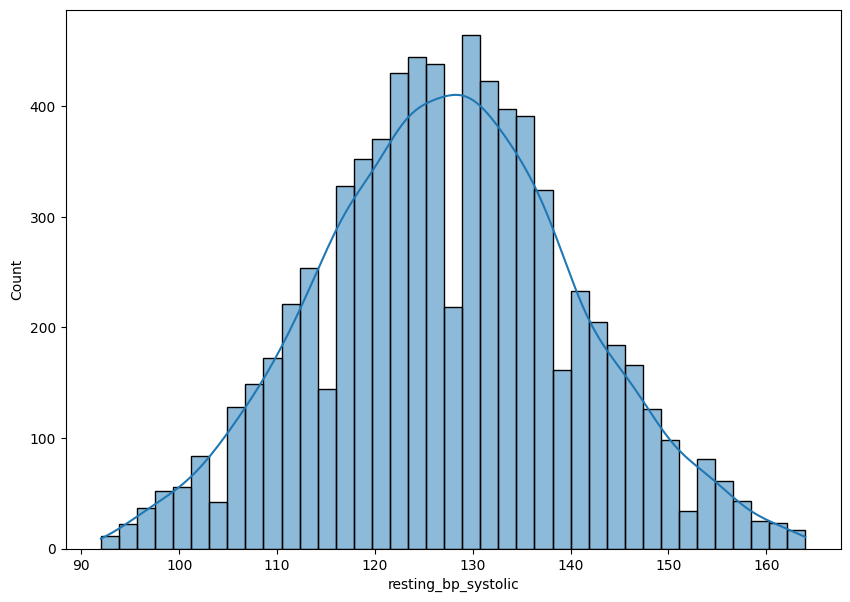

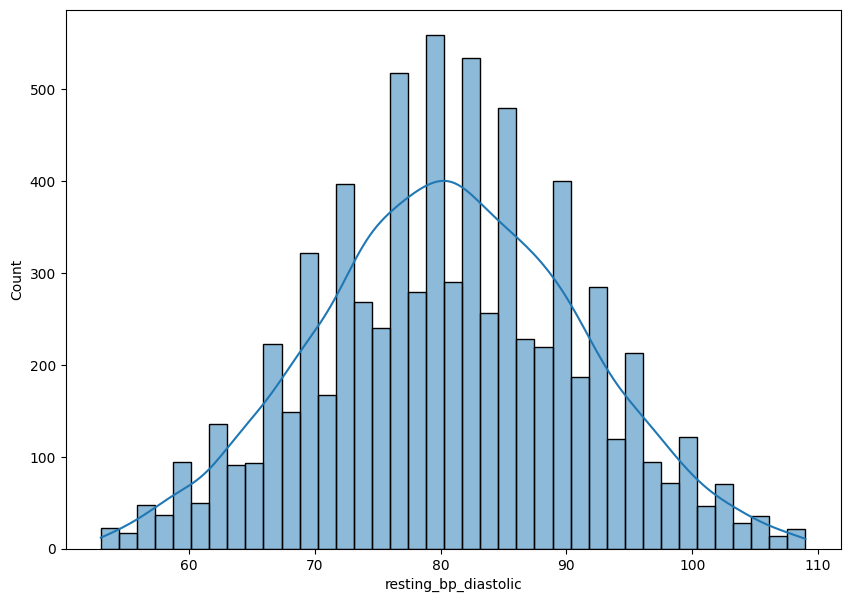

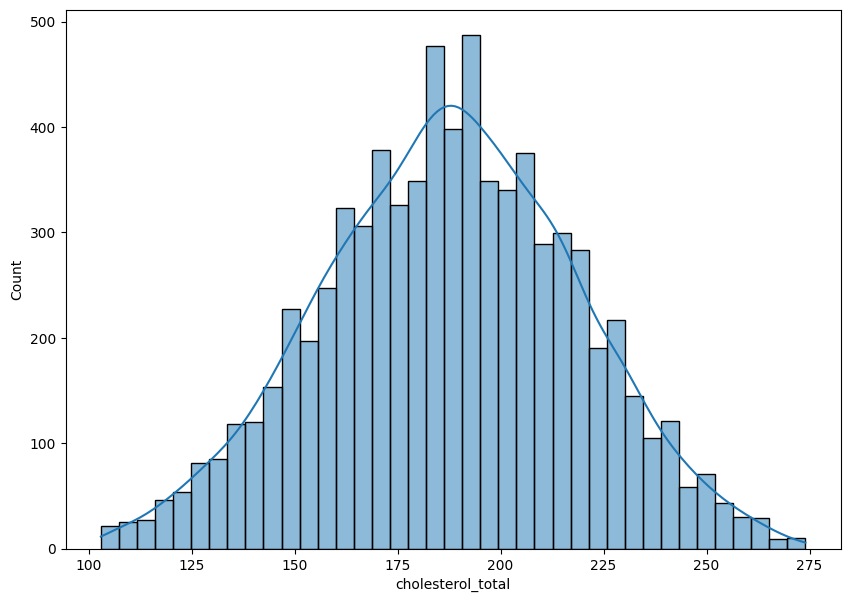

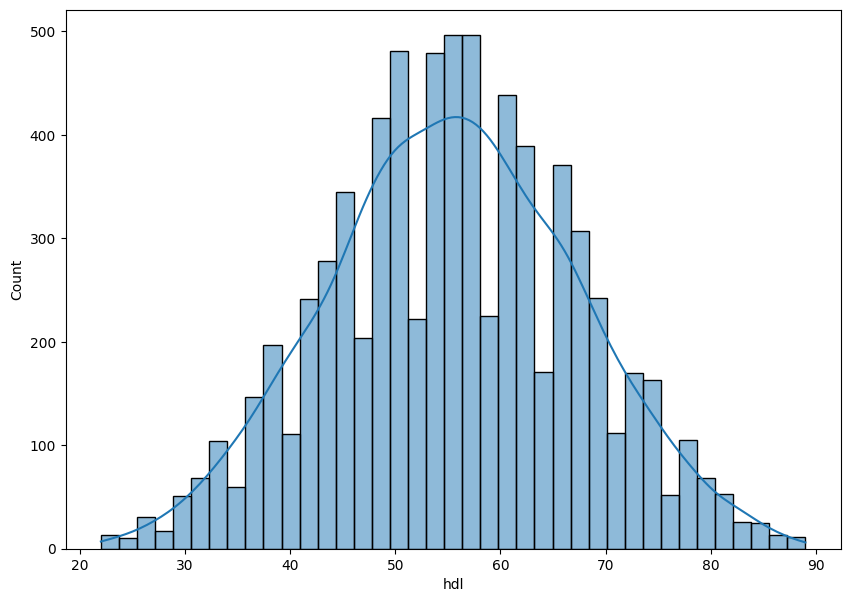

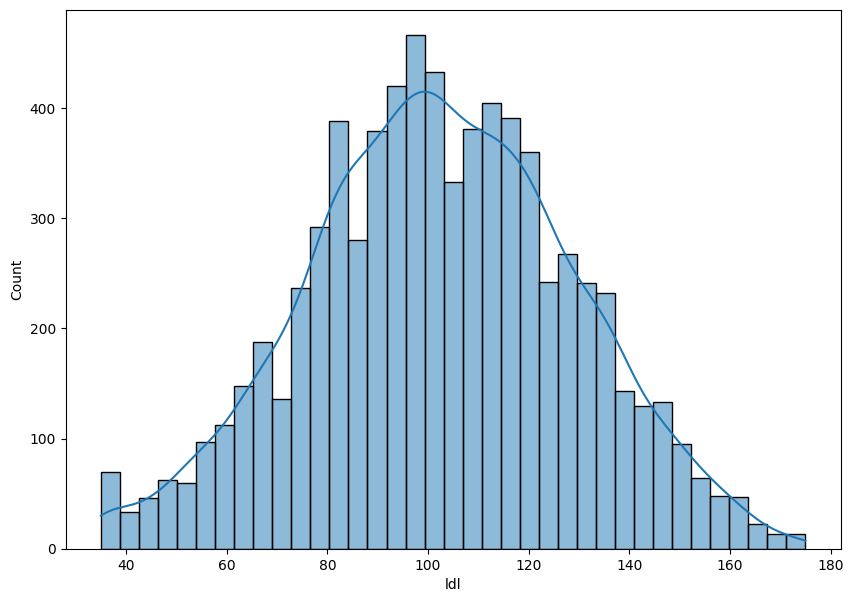

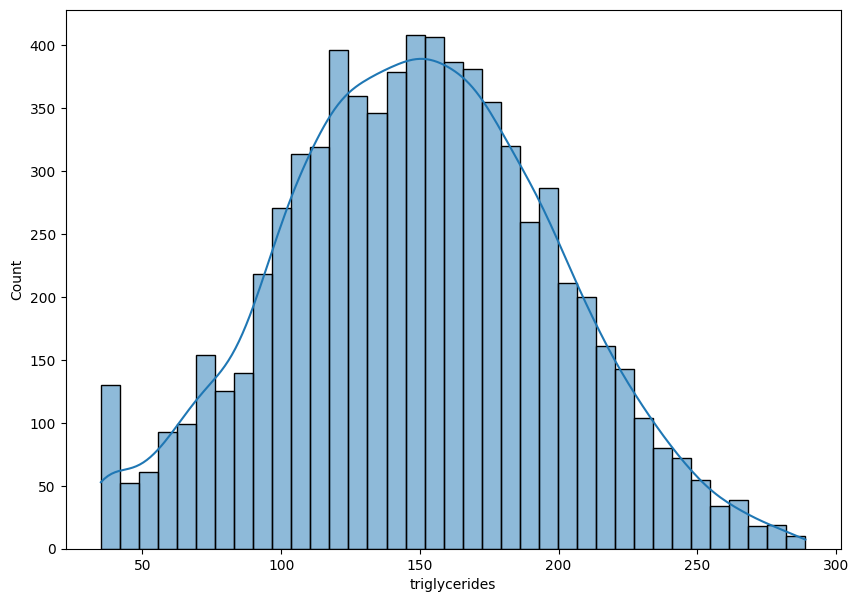

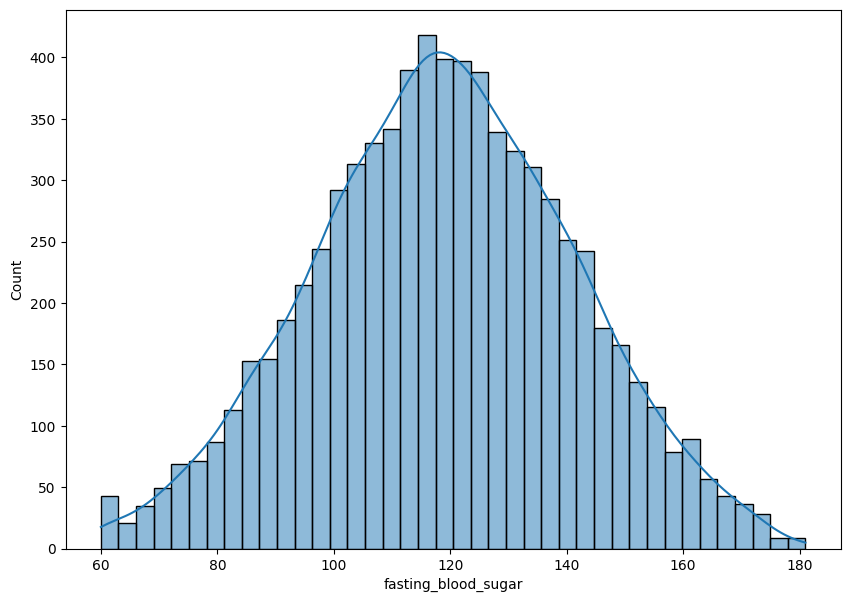

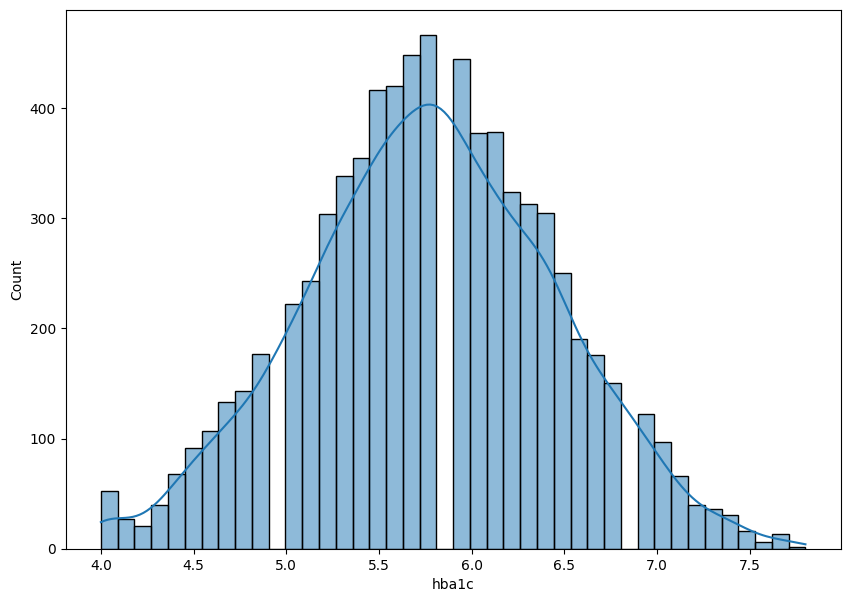

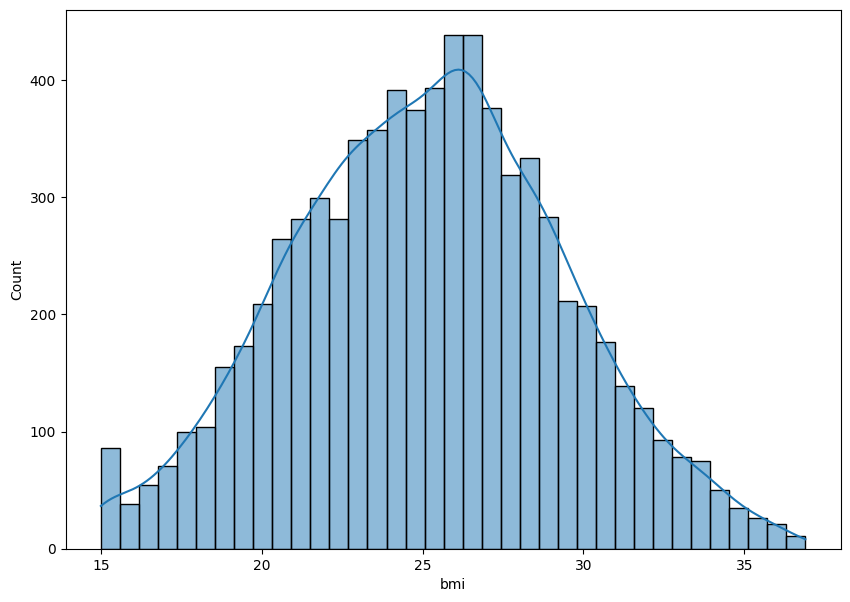

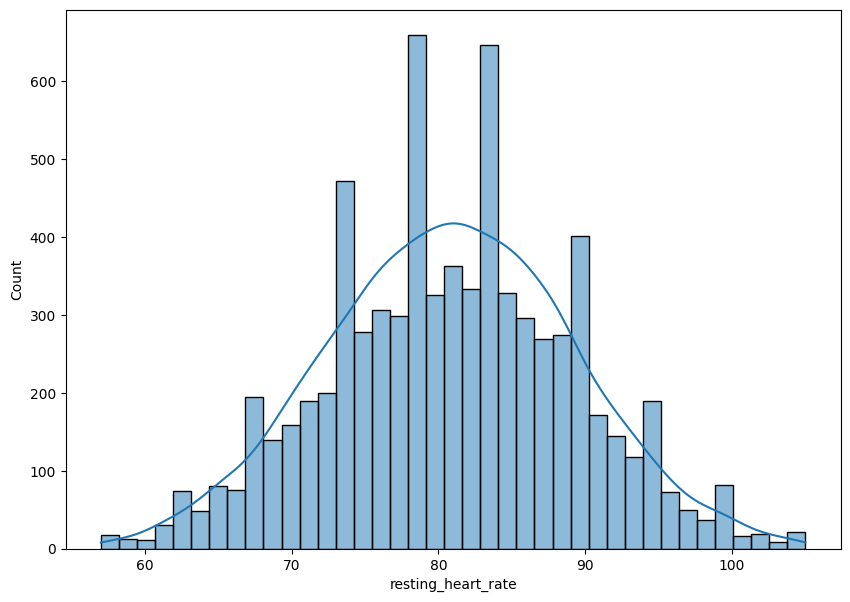

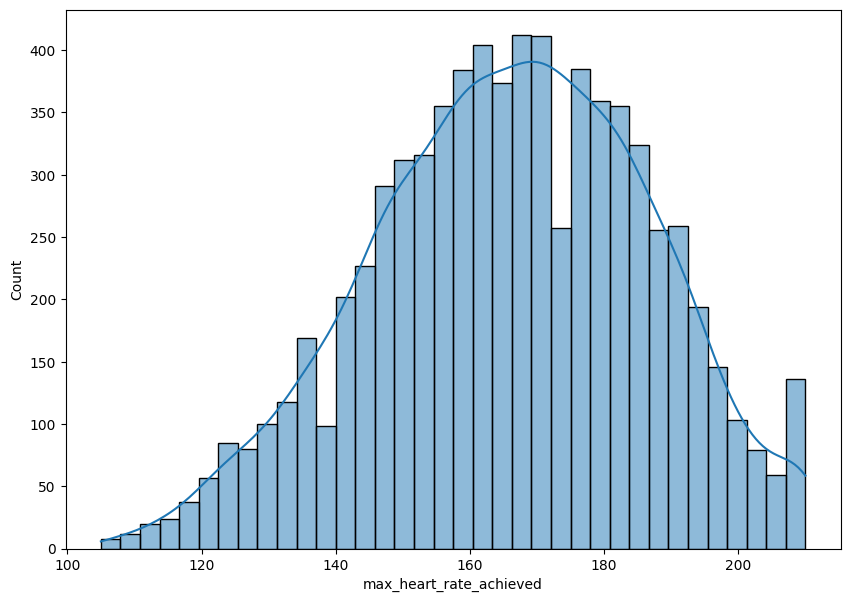

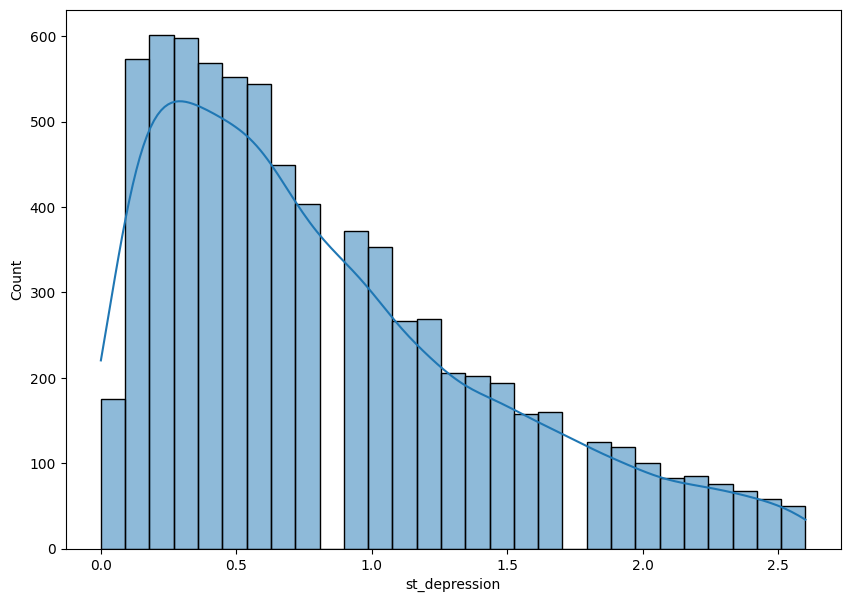

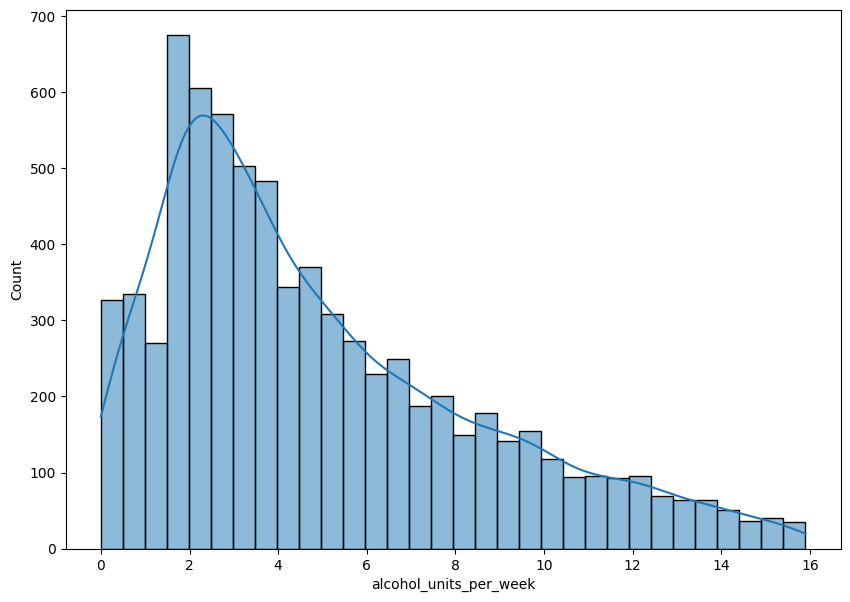

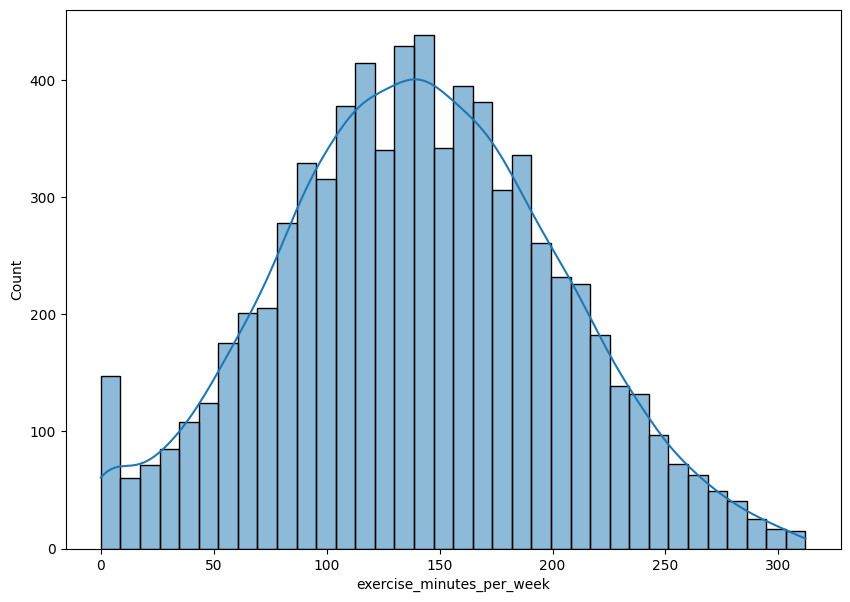

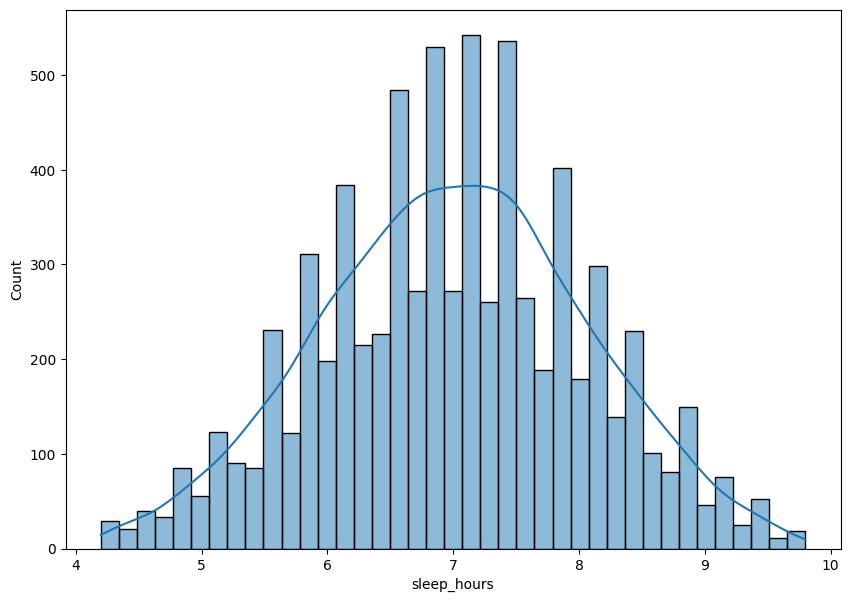

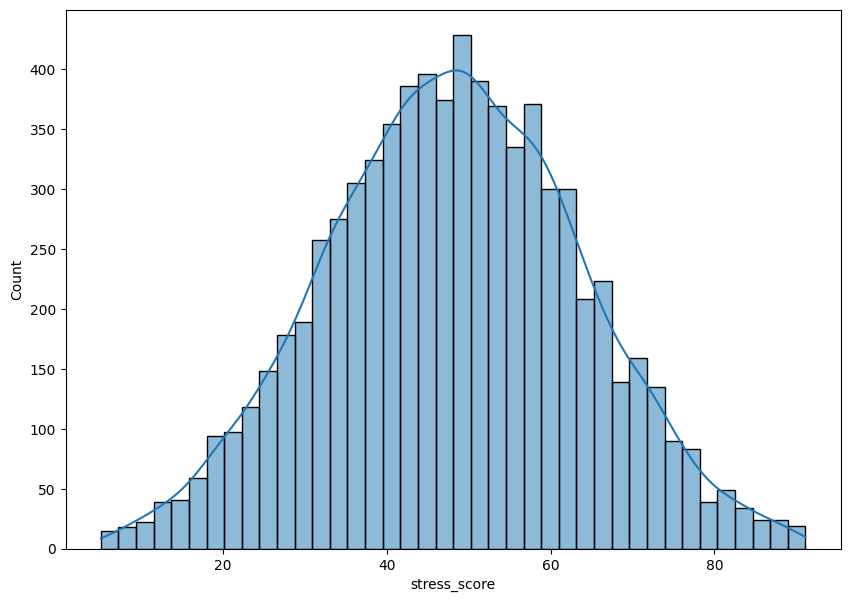

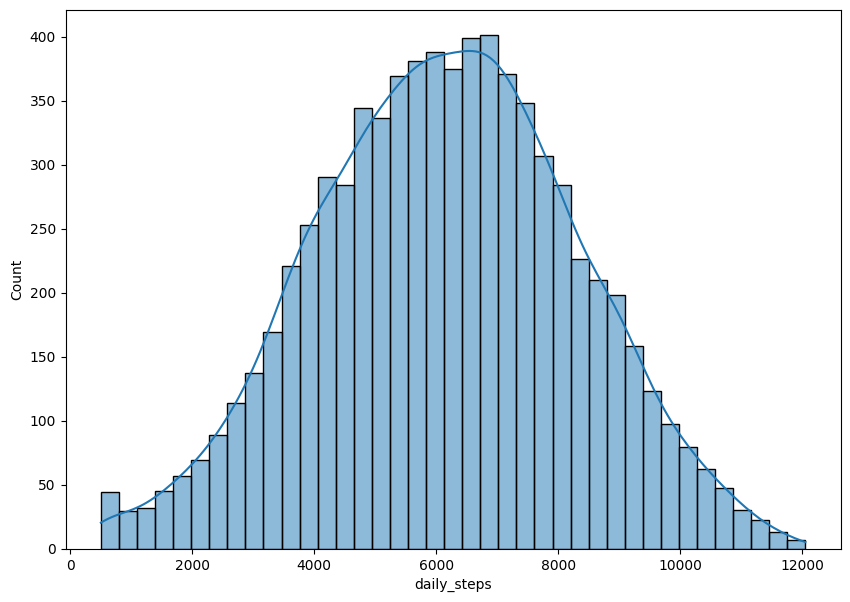

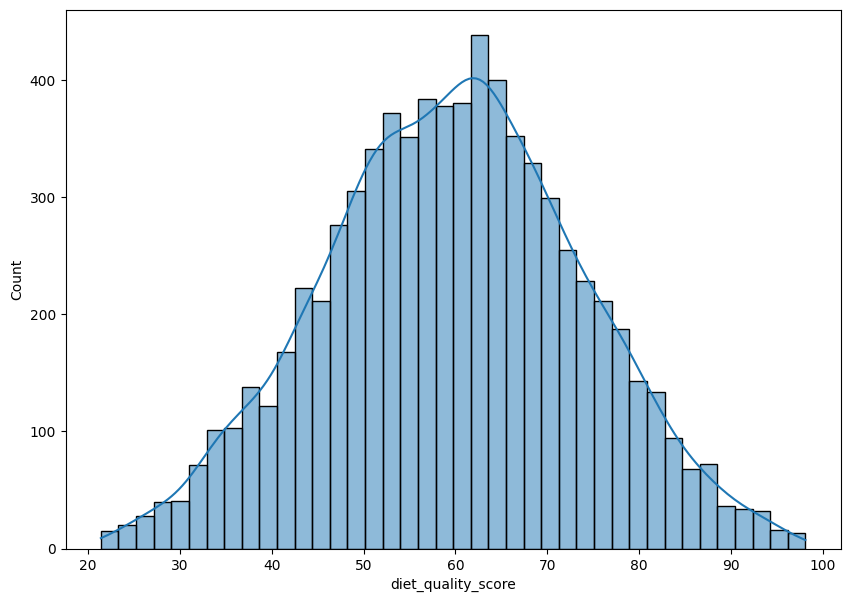

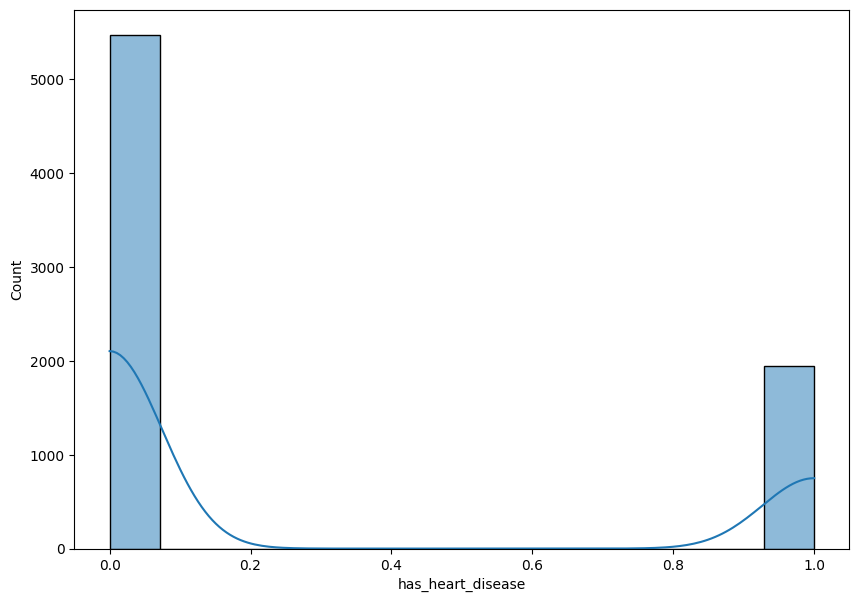

In [19]:
for col in num_cols:
  plt.figure(figsize=(10 , 7))
  sns.histplot(df[col], kde=True)
plt.show()

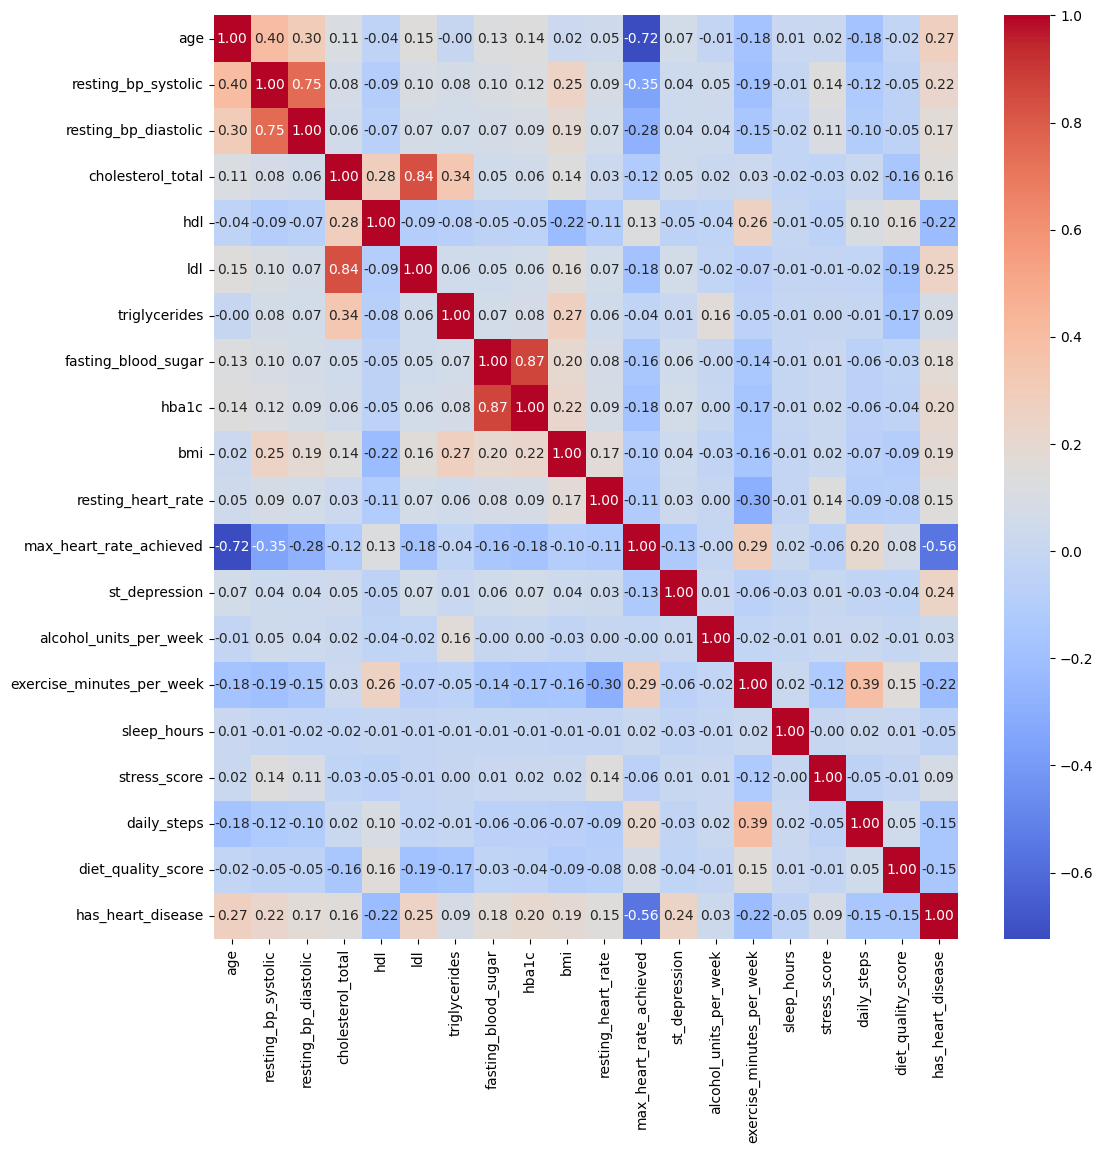

In [23]:
plt.figure(figsize=(12 , 12))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.show()

In [24]:
df

,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,44,Male,117,74,193,57,106,119,112,5.2,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,57,Male,139,94,185,69,110,35,114,5.9,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,29,Male,128,78,197,52,108,157,95,5.5,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,72,Male,132,86,197,59,104,143,92,4.8,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,62,Female,116,75,154,65,75,104,135,6.2,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,36,Female,108,63,178,68,82,158,96,5.3,...,False,Never,13.0,306,8.6,51.1,False,7144,58.1,0
8996,44,Female,112,73,213,54,139,102,125,5.9,...,False,Former,3.4,76,6.5,37.1,False,7395,68.9,0
8997,57,Female,144,93,198,66,113,79,102,5.7,...,False,Never,3.9,194,6.2,46.3,False,7424,70.2,0
8998,61,Female,130,70,220,68,135,109,104,5.5,...,False,Former,3.9,139,5.0,66.5,False,5716,43.8,1


In [25]:
X = df.drop('has_heart_disease', axis=1)
y = df['has_heart_disease']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
real_num_cols = [col for col in num_cols if col != 'has_heart_disease']

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('one-hot', OneHotEncoder(handle_unknown = 'ignore'))
])

In [29]:
num_pipeline

Pipeline(steps=[('scaler', StandardScaler())])

In [30]:
cat_pipeline

Pipeline(steps=[('one-hot', OneHotEncoder(handle_unknown='ignore'))])

In [31]:
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline , real_num_cols)
])

In [32]:
from sklearn.tree import DecisionTreeClassifier

full_pipeline = Pipeline([
    ('preprocess' , transformer),
    ('tree', DecisionTreeClassifier(max_depth=8, random_state=42))
])

In [33]:
full_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'chest_pain_type',
                                                   'smoker_status']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'resting_bp_systolic',
                                                   'resting_bp_diastolic',
                                                   'cholesterol_total', 'hdl',
                                                   'ldl', 'triglycerides',
                                                   'fasting_blood_sugar',
                                                   'hba1c', 'bmi',
                                                   'resting_heart_rate',
                                                   'max_heart_rate_achieved',
                                                   'st_depression',
                                                   'alcohol_units_per_week',
                                                   'exercise_minutes_per_week',
                                                   'sleep_hours',
                                                   'stress_score',
                                                   'daily_steps',
                                                   'diet_quality_score'])])),
                ('tree', DecisionTreeClassifier(max_depth=8, random_state=42))])

In [34]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'chest_pain_type',
                                                   'smoker_status']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'resting_bp_systolic',
                                                   'resting_bp_diastolic',
                                                   'cholesterol_total', 'hdl',
                                                   'ldl', 'triglycerides',
                                                   'fasting_blood_sugar',
                                                   'hba1c', 'bmi',
                                                   'resting_heart_rate',
                                                   'max_heart_rate_achieved',
                                                   'st_depression',
                                                   'alcohol_units_per_week',
                                                   'exercise_minutes_per_week',
                                                   'sleep_hours',
                                                   'stress_score',
                                                   'daily_steps',
                                                   'diet_quality_score'])])),
                ('tree', DecisionTreeClassifier(max_depth=8, random_state=42))])

In [35]:
full_pipeline.score(X_test, y_test)

0.8218623481781376

In [36]:
df['has_heart_disease'].value_counts(normalize=True ) * 100

,proportion
has_heart_disease,
0,73.717603
1,26.282397
